In [18]:
# Import packages
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import matplotlib.pyplot as plt
import re
import os
import sys
from scipy.sparse import csr_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import matplotlib
import harmony
%matplotlib inline

In [19]:
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/adata.combined.postprocess.h5ad')

In [20]:
print(' '.join(adata.obs['Sample'].unique()))

146_M_BASE_CTRL_1 146_M_HISC_CTRL_1 146_P_HISC_ZFPKD_1 146_M_Dediff_CTRL_1 146_P_HISC_CTRL_1 146_P_BASE_ZFPKD_2 146_P_BASE_CTRL_1 146_P_Dediff_ZFPKD_1 146_M_HISC_ZFPKD_2 146_M_HISC_ZFPKD_1 146_P_BASE_ZFPKD_1 146_P_Dediff_ZFPKD_2 146_P_Dediff_CTRL_1 146_M_Dediff_ZFPKD_2 146_P_HISC_ZFPKD_2 146_M_BASE_ZFPKD_2 146_M_BASE_ZFPKD_1 146_M_Dediff_ZFPKD_1


In [2]:
# Set plotting settings
sns.set_style('white')
matplotlib.rcParams['figure.figsize'] = [4, 4]
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['image.cmap'] = 'Spectral_r'
matplotlib.rcParams['savefig.dpi'] = 150
matplotlib.style.use("ggplot")
warnings.filterwarnings(action="ignore", module="matplotlib", message="findfont")

In [3]:
# Load data
adata_org = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/adata.combined.postprocess.h5ad')
adata_patient = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/KG146_Patient_Organoid.h5ad')

In [93]:
# Feature selection with Wilcoxon 
adata_patient.obs['Cell State'].value_counts()

sc.tl.rank_genes_groups(adata_patient, groupby='Cell State', method='wilcoxon', n_genes=100, use_raw=False)

sig_degs_df = sc.get.rank_genes_groups_df(adata_patient, group=['ISC-like', 'Injury Repair', 
                                                  'SCC', 'TA-like', 
                                                  'Goblet-like', 'Enterocyte-like', 'Fetal Progenitor', 
                                                  'Early NET'], 
                            pval_cutoff=0.001, log2fc_min=3)

deg_names = sig_degs_df['names'].tolist()

# Also make sure to include NE markers in the list of DEGs
NE_markers = ['CHGA','CHGB','SYP','ENO2','NCAM1','INSM1']
deg_names.extend(gene for gene in NE_markers if gene not in deg_names)
len(deg_names)

312

In [19]:
# Subset adata_org to include only DEGs
# Get the intersection of deg_names and adata_org.var_names
common_genes = set(deg_names) & set(adata_org.var_names)

# Subset adata_org to include only common genes
adata_org2 = adata_org[:, list(common_genes)].copy()

In [32]:
# Subset adata_patient to have the same genes as adata_org
# Get common genes between adata_patient and adata_org2
common_genes_patient = set(adata_patient.var_names) & set(adata_org2.var_names)

# Subset adata_patient to include only common genes
adata_patient_subset = adata_patient[:, list(common_genes_patient)].copy()

In [37]:
# Access the count matrix of adata_patient_subset
adata_patient_subset.X

<1304x240 sparse matrix of type '<class 'numpy.float64'>'
	with 120869 stored elements in Compressed Sparse Row format>

In [6]:
unique_samples = adata_org.obs['Sample'].unique()
unique_samples

['146_M_BASE_CTRL_1', '146_M_HISC_CTRL_1', '146_P_HISC_ZFPKD_1', '146_M_Dediff_CTRL_1', '146_P_HISC_CTRL_1', ..., '146_M_Dediff_ZFPKD_2', '146_P_HISC_ZFPKD_2', '146_M_BASE_ZFPKD_2', '146_M_BASE_ZFPKD_1', '146_M_Dediff_ZFPKD_1']
Length: 18
Categories (18, object): ['146_M_BASE_CTRL_1', '146_M_BASE_ZFPKD_1', '146_M_BASE_ZFPKD_2', '146_M_Dediff_CTRL_1', ..., '146_P_Dediff_ZFPKD_2', '146_P_HISC_CTRL_1', '146_P_HISC_ZFPKD_1', '146_P_HISC_ZFPKD_2']

In [ ]:
unique_samples = adata_org.obs['Sample'].unique()
unique_samples

In [12]:
unique_samples = adata_org.obs['Sample'].unique()
unique_samples

['146_M_BASE_CTRL_1', '146_M_HISC_CTRL_1', '146_P_HISC_ZFPKD_1', '146_M_Dediff_CTRL_1', '146_P_HISC_CTRL_1', ..., '146_M_Dediff_ZFPKD_2', '146_P_HISC_ZFPKD_2', '146_M_BASE_ZFPKD_2', '146_M_BASE_ZFPKD_1', '146_M_Dediff_ZFPKD_1']
Length: 18
Categories (18, object): ['146_M_BASE_CTRL_1', '146_M_BASE_ZFPKD_1', '146_M_BASE_ZFPKD_2', '146_M_Dediff_CTRL_1', ..., '146_P_Dediff_ZFPKD_2', '146_P_HISC_CTRL_1', '146_P_HISC_ZFPKD_1', '146_P_HISC_ZFPKD_2']

In [9]:
unique_samples = adata_org.obs['Sample'].unique()

for sample in unique_samples:
    # Subset the data for the current sample
    adata_subset = adata_org2[adata_org2.obs['Sample'] == sample].copy()

In [16]:
for sample in unique_samples: 
    print(sample)
    adata_org2 = adata_org[adata_org.obs['Sample'] == sample].copy()

146_M_BASE_CTRL_1
146_M_HISC_CTRL_1
146_P_HISC_ZFPKD_1
146_M_Dediff_CTRL_1
146_P_HISC_CTRL_1
146_P_BASE_ZFPKD_2
146_P_BASE_CTRL_1
146_P_Dediff_ZFPKD_1
146_M_HISC_ZFPKD_2
146_M_HISC_ZFPKD_1
146_P_BASE_ZFPKD_1
146_P_Dediff_ZFPKD_2
146_P_Dediff_CTRL_1
146_M_Dediff_ZFPKD_2
146_P_HISC_ZFPKD_2
146_M_BASE_ZFPKD_2
146_M_BASE_ZFPKD_1
146_M_Dediff_ZFPKD_1


In [17]:
adata_subset

AnnData object with n_obs × n_vars = 2117 × 31806
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_pca', 'X_u

In [10]:
adata_subset

AnnData object with n_obs × n_vars = 2117 × 31806
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_pca', 'X_u

In [7]:
for sample in unique_samples: 
    adata_org2 = adata_org[adata_org.obs.Sample.str.contains(sample),:].copy()

In [8]:
adata_org2

AnnData object with n_obs × n_vars = 2117 × 31806
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_pca', 'X_u

In [151]:
# Choose the sample
sample = 'P_BASE'
adata_org2 = adata_org[adata_org.obs.Sample.str.contains(sample),:].copy()

In [152]:
adata_org2

AnnData object with n_obs × n_vars = 11418 × 31806
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_pca', 'X_

In [153]:
# Prepare data
adata_patient = adata_patient[~adata_patient.obs.loc[:,'Cell State'].isin(['nan','NA']),:].copy()
mat_2 = pd.DataFrame(adata_org2.raw.X, index=adata_org2.raw.obs_names, columns=adata_org2.raw.var_names)
mat_1 = pd.DataFrame(adata_patient.raw.X.todense(), index=adata_patient.raw.obs_names, columns=adata_patient.raw.var_names)

mat_1.index = 'Patient_' + mat_1.index
mat_2.index = 'Org_' + mat_2.index

mat = pd.concat([mat_1, mat_2], join='outer').fillna(0).astype(int)

In [154]:
# Normalize and visualize
adata = sc.AnnData(mat)
adata.raw = adata

sc.pp.calculate_qc_metrics(adata, inplace=True)
adata.obs.loc[:,'log10GenesPerUMI'] =(np.log10(adata.obs.n_genes_by_counts)).div(np.log10(adata.obs.total_counts))

adata.obs['sample'] = [re.sub('_[0-9]+$','',i) for i in adata.obs_names]

sc.pp.filter_genes(adata, min_cells=1)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata, base = 2)

adata.layers['counts'] = adata.raw[:,adata.var_names].X

adata.obs['Modality'] = adata.obs.index.str.replace('_.*','', regex=True)

In [155]:
# Feature selection with HVGs
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=500,
    layer="counts",
    flavor="seurat_v3",  # Change to "seurat"
    batch_key="Modality"
)

NE_markers = ['CHGA','CHGB','SYP','ENO2','NCAM1','INSM1']

adata.var.loc[NE_markers, 'highly_variable'] = True

sc.tl.pca(adata, use_highly_variable = True)

In [156]:
# Define timepoint connections
timepoint_connections = pd.DataFrame(columns=[0, 1])
index = 0
timepoint_connections.loc[index, :] = ['Org', 'Patient']; index += 1

tp = adata.obs.Modality

In [157]:
# Construct affinity matrix
def _convert_to_affinity(adj, scaling_factors, device, with_self_loops=False):
    """ Convert adjacency matrix to affinity matrix
    """
    N = adj.shape[0]
    rows, cols, dists = find(adj)
    if device == "gpu":
        import cupy as cp
        from cupyx.scipy.sparse import csr_matrix as csr_matrix_gpu
        dists = cp.array(dists) ** 2/(cp.array(scaling_factors.values[rows]) ** 2)
        rows, cols = cp.array(rows), cp.array(cols)
        # Self loops
        if with_self_loops:
            dists = cp.append(dists, cp.zeros(N))
            rows = cp.append(rows, range(N))
            cols = cp.append(cols, range(N))
        aff = csr_matrix_gpu((cp.exp(-dists), (rows, cols)), shape=(N, N)).get()
    elif device == "cpu":
        dists = dists ** 2/(scaling_factors.values[rows] ** 2)

        # Self loops
        if with_self_loops:
            dists = np.append(dists, np.zeros(N))
            rows = np.append(rows, range(N))
            cols = np.append(cols, range(N))
        aff = csr_matrix((np.exp(-dists), (rows, cols)), shape=[N, N])
    return aff


In [158]:
# Construct MNN graph
def _construct_mnn(t1_cells, t2_cells, data_df, n_neighbors,device,n_jobs=-2):
    # FUnction to construct mutually nearest neighbors bewteen two points
    
    if device == "gpu":
        from cuml import NearestNeighbors
        nbrs = NearestNeighbors(n_neighbors=n_neighbors,
                                metric='cosine')
    elif device == "cpu":
        from sklearn.neighbors import NearestNeighbors
        nbrs = NearestNeighbors(n_neighbors=n_neighbors,
                                metric='cosine', n_jobs=n_jobs)
    
    print(f't+1 neighbors of t...')
    nbrs.fit(data_df.loc[t1_cells, :].values)
    t1_nbrs = nbrs.kneighbors_graph(
        data_df.loc[t2_cells, :].values, mode='distance')

    print(f't neighbors of t+1...')
    nbrs.fit(data_df.loc[t2_cells, :].values)
    t2_nbrs = nbrs.kneighbors_graph(
        data_df.loc[t1_cells, :].values, mode='distance')

    # Mututally nearest neighbors
    mnn = t2_nbrs.multiply(t1_nbrs.T)
    mnn = mnn.sqrt()
    return mnn

In [159]:
# Compute scaling factors
def _mnn_scaling_factors(mnn_ka_dists, scaling_factors,device):
    if device == "gpu":
        from cuml import LinearRegression
    else:
        from sklearn.linear_model import LinearRegression
    cells = mnn_ka_dists.index[~mnn_ka_dists.isnull()]

    # Linear model fit
    x = scaling_factors[cells]
    y = mnn_ka_dists[cells]
    lm = LinearRegression()
    lm.fit(x.values.reshape(-1, 1), y.values.reshape(-1, 1))

    # Predict
    x = scaling_factors[mnn_ka_dists.index]
    vals = np.ravel(lm.predict(x.values.reshape(-1, 1)))
    mnn_scaling_factors = pd.Series(vals, index=mnn_ka_dists.index)

    return mnn_scaling_factors

In [160]:
# Construct affinity matrix
def _mnn_affinity(mnn, mnn_scaling_factors, offset1, offset2, device):
    # Function to convert mnn matrix to affinicty matrix

    # Construct adjacency matrix
    N = len(mnn_scaling_factors)
    x, y, z = find(mnn)
    x = x + offset1
    y = y + offset2
    adj = csr_matrix((z, (x, y)), shape=[N, N])

    # Affinity matrix
    return _convert_to_affinity(adj, mnn_scaling_factors, device, False)

In [161]:
'''
Harmony and Palantir
'''
def _mnn_ka_distances(mnn, n_neighbors):
    # Function to find distance ka^th neighbor in the mutual nearest neighbor matrix
    ka = int(n_neighbors / 3)
    ka_dists = np.repeat(None, mnn.shape[0])
    x, y, z = find(mnn)
    rows=pd.Series(x).value_counts()
    for r in rows.index[rows >= ka]:
        ka_dists[r] = np.sort(z[x==r])[ka - 1]
    return ka_dists

from harmony import core
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import find, csr_matrix

def harmony_aug_mat_with_pca(projections, timepoints, timepoint_connections, n_neighbors, n_neighbors2):
    # Time point cells and indices
    tp_cells = pd.Series()
    tp_offset = pd.Series()
    offset = 0
    for i in timepoints.unique():
        tp_offset[i] = offset
        tp_cells[i] = list(timepoints.index[timepoints == i])
        offset += len(tp_cells[i])

    # Nearest neighbor graph construction and affinity matrix
    print('Nearest neighbor computation...')
    nbrs = NearestNeighbors(n_neighbors=n_neighbors,
                            metric='cosine', n_jobs=-2).fit(projections.values)

    adj = nbrs.kneighbors_graph(projections.values, mode='distance')
    dists, _ = nbrs.kneighbors(projections.values)
    
    # Scaling factors for affinity matrix construction
    ka = int(n_neighbors / 3)
    scaling_factors = pd.Series(dists[:, ka], index=projections.index)
    
    # Affinity matrix
    nn_aff = _convert_to_affinity(adj, scaling_factors, 'cpu', True)
    n_jobs = -2
    
    # Mututally nearest neighbor affinity matrix
    # Initilze mnn affinity matrix
    N = projections.shape[0]
    full_mnn_aff = csr_matrix(([0], ([0], [0])), [N, N])
    for i in timepoint_connections.index:
        t1, t2 = timepoint_connections.loc[i, :].values
        print(f'Constucting affinities between {t1} and {t2}...')
        # MNN matrix  and distance to ka the distance
        t1_cells = tp_cells[t1]
        t2_cells = tp_cells[t2]
        mnn = _construct_mnn(t1_cells, t2_cells, projections,
                             n_neighbors2, 'cpu', n_jobs)
        
        # MNN Scaling factors
        # Distance to the adaptive neighbor
        ka_dists = pd.Series(0.0, index=t1_cells + t2_cells)
        ka_dists = ka_dists.astype(float)
        # T1 scaling factors
        ka_dists[t1_cells] = _mnn_ka_distances(mnn, n_neighbors2)
        # T2 scaling factors
        ka_dists[t2_cells] = _mnn_ka_distances(mnn.T, n_neighbors2)
        # Scaling factors
        mnn_scaling_factors = pd.Series(0.0, index=projections.index)
#         mnn_scaling_factors[t1_cells] = core._mnn_scaling_factors(
#             ka_dists[t1_cells], scaling_factors,'cpu')
#         mnn_scaling_factors[t2_cells] = core._mnn_scaling_factors(
#             ka_dists[t2_cells], scaling_factors,'cpu')
        mnn_scaling_factors[t1_cells] = _mnn_scaling_factors(
            ka_dists[t1_cells], scaling_factors,'cpu')
        mnn_scaling_factors[t2_cells] = _mnn_scaling_factors(
            ka_dists[t2_cells], scaling_factors,'cpu')
        
        # MNN affinity matrix
#         full_mnn_aff = full_mnn_aff + \
#             core._mnn_affinity(mnn, mnn_scaling_factors,
#                           tp_offset[t1], tp_offset[t2], 'cpu')
        full_mnn_aff = full_mnn_aff + \
            _mnn_affinity(mnn, mnn_scaling_factors,
                          tp_offset[t1], tp_offset[t2], 'cpu')
    # Symmetrize the affinity matrix and return
    aug_aff2 = nn_aff + nn_aff.T + full_mnn_aff + full_mnn_aff.T
    aff2 = nn_aff + nn_aff.T
    return aug_aff2, aff2

In [162]:
# Compute augmented and affinity matrix
n_neighbors = 15
n_neighbors2 = 30
pca_merge = pd.DataFrame(adata.obsm['X_pca'], index=adata.obs_names)
aug_mat, aff_mat = harmony_aug_mat_with_pca(pca_merge, tp, timepoint_connections, n_neighbors, n_neighbors2)

Nearest neighbor computation...
Constucting affinities between Org and Patient...
t+1 neighbors of t...
t neighbors of t+1...


In [163]:
# Add aug_mat to adata_patient_organoid
adata.obsm['aug_mat'] = aug_mat.toarray()

# Add aff_mat to adata_patient_organoid
adata.obsm['aff_mat'] = aff_mat.toarray()

aug_mat = pd.DataFrame(adata.obsm['aug_mat'], index=adata.obs.index, columns = adata.obs.index)

In [164]:
# Prepare data to define cell state
bc_intersect = ('Patient_' + adata_patient.obs.index).intersection(adata.obs.index)

adata.obs['Cell State'] = 'nan'
adata.obs.loc[bc_intersect, 'Cell State'] = adata_patient.obs.loc[bc_intersect.str.replace('Patient_',''),'Cell State'].values

cell_types =  ['nan'] + adata.obs['Cell State'].astype('category').cat.categories[:-1].to_list()

ct_labels = adata.obs['Cell State'].astype('category').cat.reorder_categories(cell_types)

# cluster9 = 'Org_' + adata_org.obs.index[adata_org.obs.leiden_subset=='146_P_BASE_ZFPKD_1,13']
# cluster9 = aug_mat.index.intersection(cluster9)

ct_codes = ct_labels.cat.codes

In [165]:
# Compute random walk probabilities
def random_walk_probabilities(A, labels):
    D = np.diag(np.sum(A, axis=1))
    L = D - A  # graph laplacian
    seeds = np.array([e != 0 for e in labels], dtype=bool)
    Lu = L[np.invert(seeds),:][:, np.invert(seeds)]  # unlabeled rows, unlabeled cols
    BT = L[np.invert(seeds),:][:, seeds]  # unlabeled rows, labeled cols
    classes = np.unique(labels[labels > 0])
    M = np.zeros((seeds.sum(), len(classes)))
    for k in classes:
        M[labels[seeds] == k, k-1] = 1
    P = np.linalg.lstsq(Lu, np.dot(-BT, M), rcond = None)[0]
    return P

In [166]:
# Compute random walk probabilities
P = random_walk_probabilities(aug_mat.values, ct_codes.values)

In [167]:
print(P)

[[0.0114579  0.25908255 0.03959707 ... 0.13016004 0.0031362  0.12849375]
 [0.00656774 0.36104761 0.01516727 ... 0.13018491 0.00625489 0.19091458]
 [0.00825753 0.33890285 0.02413057 ... 0.14714203 0.00495621 0.14740556]
 ...
 [0.00526394 0.16531605 0.01764789 ... 0.06679364 0.00372698 0.46940059]
 [0.0065703  0.36884926 0.01461356 ... 0.13632686 0.00682111 0.17098796]
 [0.00770391 0.28109954 0.02126444 ... 0.11374819 0.00615339 0.26525605]]


In [168]:
ct_prob = pd.DataFrame(P, index= aug_mat.index[ct_codes==0], columns = cell_types[1:])

In [169]:
ct_prob

,Early NET,Enterocyte-like,Fetal Progenitor,Goblet-like,ISC-like,Injury Repair,SCC,TA-like
Org_146P_BASE_shZFP36L2_4_GAGTGAGGTGTAACGG-1,0.011458,0.259083,0.039597,0.236407,0.191665,0.130160,0.003136,0.128494
Org_146P_BASE_shCTRL_GCTCAAAAGCGAGGAG-1,0.006568,0.361048,0.015167,0.078209,0.211654,0.130185,0.006255,0.190915
Org_146P_BASE_shCTRL_TAATTCCGTCCTCAGG-1,0.008258,0.338903,0.024131,0.114236,0.214969,0.147142,0.004956,0.147406
Org_146P_BASE_shZFP36L2_3_ATCACTTTCTGGAGAG-1,0.004184,0.451522,0.008760,0.049533,0.199746,0.084245,0.005267,0.196743
Org_146P_BASE_shZFP36L2_4_TAGCACAAGGTATAGT-1,0.008135,0.348873,0.022858,0.121451,0.211892,0.133417,0.005221,0.148154
...,...,...,...,...,...,...,...,...
Org_146P_BASE_shZFP36L2_4_TGAGGTTCACGGTGAA-1,0.002178,0.102266,0.005344,0.104561,0.064195,0.036760,0.002586,0.682109
Org_146P_BASE_shCTRL_GCTTGGGGTCTGTAGT-1,0.003993,0.186289,0.008878,0.063768,0.130078,0.069644,0.005663,0.531687
Org_146P_BASE_shZFP36L2_3_GCTACCTAGACGACGT-1,0.005264,0.165316,0.017648,0.168339,0.103512,0.066794,0.003727,0.469401
Org_146P_BASE_shCTRL_AGTAGTCGTAGCTTTG-1,0.006570,0.368849,0.014614,0.075519,0.220312,0.136327,0.006821,0.170988


In [170]:
adata_org2

AnnData object with n_obs × n_vars = 11418 × 31806
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_pca', 'X_

In [171]:
# Remove 'Org_' from the row names
ct_prob.index = ct_prob.index.str.replace('Org_', '')
ct_pred = ct_prob.idxmax(axis=1)

# Check if the index matches adata_org2.obs_names
if set(ct_prob.index) == set(adata_org2.obs_names):
    # Add the entire DataFrame to adata_org2.obs
    adata_org2.obs = pd.concat([adata_org2.obs, ct_prob], axis=1)
    adata_org2.obs['Cell State'] = ct_pred
else:
    print("Error: Index mismatch between ct_prob and adata_org2.obs_names")

In [172]:
adata_org2.obs

,background_fraction,cell_probability,cell_size,droplet_efficiency,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,leiden,Early NET,Enterocyte-like,Fetal Progenitor,Goblet-like,ISC-like,Injury Repair,SCC,TA-like,Cell State
146P_BASE_shZFP36L2_4_GAGTGAGGTGTAACGG-1,0.029510,1.000000,8488.930664,1.082536,2985,8.001690,7104,8.868554,21.002252,30.588401,...,2,0.011458,0.259083,0.039597,0.236407,0.191665,0.130160,0.003136,0.128494,Enterocyte-like
146P_BASE_shCTRL_GCTCAAAAGCGAGGAG-1,0.030807,0.999998,8812.069336,1.087509,2864,7.960324,6754,8.818038,25.066627,35.193959,...,3,0.006568,0.361048,0.015167,0.078209,0.211654,0.130185,0.006255,0.190915,Enterocyte-like
146P_BASE_shCTRL_TAATTCCGTCCTCAGG-1,0.044553,1.000000,7708.493164,1.117101,2684,7.895436,6142,8.723069,22.207750,32.123087,...,2,0.008258,0.338903,0.024131,0.114236,0.214969,0.147142,0.004956,0.147406,Enterocyte-like
146P_BASE_shZFP36L2_3_ATCACTTTCTGGAGAG-1,0.019273,0.999509,10018.500977,1.248328,3145,8.053887,9150,9.121618,26.393443,38.524590,...,2,0.004184,0.451522,0.008760,0.049533,0.199746,0.084245,0.005267,0.196743,Enterocyte-like
146P_BASE_shZFP36L2_4_TAGCACAAGGTATAGT-1,0.032213,1.000000,8202.001953,1.042252,2732,7.913155,6648,8.802222,26.052948,36.928400,...,2,0.008135,0.348873,0.022858,0.121451,0.211892,0.133417,0.005221,0.148154,Enterocyte-like
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146P_BASE_shZFP36L2_4_TGAGGTTCACGGTGAA-1,0.007697,0.999955,13413.293945,1.552806,4723,8.460411,16613,9.718001,19.719497,28.543911,...,28,0.002178,0.102266,0.005344,0.104561,0.064195,0.036760,0.002586,0.682109,TA-like
146P_BASE_shCTRL_GCTTGGGGTCTGTAGT-1,0.033774,0.999999,8970.382812,1.063500,2918,7.978996,7113,8.869820,21.833263,31.800928,...,28,0.003993,0.186289,0.008878,0.063768,0.130078,0.069644,0.005663,0.531687,TA-like
146P_BASE_shZFP36L2_3_GCTACCTAGACGACGT-1,0.012010,0.999955,10935.643555,1.755016,4380,8.385032,14314,9.569063,25.087327,33.121420,...,1,0.005264,0.165316,0.017648,0.168339,0.103512,0.066794,0.003727,0.469401,TA-like
146P_BASE_shCTRL_AGTAGTCGTAGCTTTG-1,0.028843,1.000000,8719.412109,1.077544,2779,7.930206,6910,8.840870,27.684515,39.189580,...,2,0.006570,0.368849,0.014614,0.075519,0.220312,0.136327,0.006821,0.170988,Enterocyte-like


In [173]:
# Save the adata with predicted cell states and probabilities
adata_org2.write_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.cell.state.probabilities.primary.base.h5ad')

In [174]:
ct_prob.idxmax(axis=1).value_counts()

TA-like             5089
Enterocyte-like     5087
Goblet-like          860
Injury Repair        185
ISC-like              97
Early NET             78
Fetal Progenitor      21
SCC                    1
Name: count, dtype: int64

In [53]:
ct_pred_series = ct_prob.idxmax(axis=1)
ct_pred = pd.DataFrame({'ct_pred': ct_pred_series})
ct_pred

,ct_pred
146P_BASE_shZFP36L2_4_GAGTGAGGTGTAACGG-1,Enterocyte-like
146P_BASE_shZFP36L2_4_TAGCACAAGGTATAGT-1,Enterocyte-like
146P_BASE_shZFP36L2_4_TTGCATTCAAGGCGTA-1,Enterocyte-like
146P_BASE_shZFP36L2_4_TATTTCGAGAATCTAG-1,Enterocyte-like
146P_BASE_shZFP36L2_4_TTATTGCAGCGACATG-1,Enterocyte-like
...,...
146P_BASE_shZFP36L2_4_CGCATAACAATCTGCA-1,Injury Repair
146P_BASE_shZFP36L2_4_TCCCAGTCACCGGAAA-1,Enterocyte-like
146P_BASE_shZFP36L2_4_TTTGGAGAGTTCTACG-1,TA-like
146P_BASE_shZFP36L2_4_ATCTCTAGTACTAACC-1,Injury Repair


In [34]:
ct_pred = ct_prob.idxmax(axis=1)

# adata_org.obs.loc[:,'ct_pred'] = 'NA'
# adata_org.obs.loc[ct_pred.index.str.replace('Org_',''),'ct_pred'] = ct_pred.values

adata_org.obs.loc[:,'ct_pred'] = 'NA'
adata_org.obs.loc[ct_pred.index.str.replace('Org_', ''),'ct_pred'] = ct_pred.values
adata_org.obs

,background_fraction,cell_probability,cell_size,droplet_efficiency,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,Patient,Tumor_Site,Culture_Media,ZFP_Expression,Replicate,Batch,Sample,phenograph,leiden,ct_pred
KG146Li_BASE_shCtrl_TGCGGGTTCTCACCCA-1,0.122256,0.999999,9510.026367,0.782633,1127,7.028201,2686,7.896181,49.404319,54.988831,...,146,Metastatic,BASE,CTRL,1,2,146_M_BASE_CTRL_1,12,11,NA
KG146Li_HISC_shCtrl_ACTATCTGTAACGGTG-1,0.071823,0.999999,7005.529297,0.771213,1320,7.186144,2528,7.835579,42.761076,47.112342,...,146,Metastatic,HISC,CTRL,1,3,146_M_HISC_CTRL_1,19,6,NA
146P_HISC_shZFP36L2_3_TTGTGTTTCCCAAGTA-1,0.031075,0.999950,14507.531250,1.027227,3045,8.021585,9831,9.193398,30.708982,44.634320,...,146,Primary,HISC,ZFP_KD,1,6,146_P_HISC_ZFPKD_1,10,13,NA
146Li_dedifferentiation_shCtrl_ATCGATGCACGGAAGT-1,0.033828,0.999974,12912.831055,1.133512,3009,8.009695,8806,9.083302,35.010220,47.172382,...,146,Metastatic,Dedifferentiated,CTRL,1,4,146_M_Dediff_CTRL_1,25,29,NA
146P_HISC_shCTRL_GTCGCGACAAGGCTTT-1,0.053984,0.999998,13370.254883,0.725564,2447,7.803027,6547,8.786915,27.157477,39.376814,...,146,Primary,HISC,CTRL,1,6,146_P_HISC_CTRL_1,11,21,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146P_dedifferentiation_shCtrl_CTCCGATTCATTCATC-1,0.097506,0.999994,13538.197266,0.864753,2075,7.638198,4775,8.471359,45.026178,49.759162,...,146,Primary,Dedifferentiated,CTRL,1,8,146_P_Dediff_CTRL_1,3,12,NA
KG146Li_BASE_shZFP36L2_4_CTGCTCAAGTAGCAAT-1,0.010058,0.999955,17959.175781,1.036444,4895,8.496174,16396,9.704854,24.646255,33.355697,...,146,Metastatic,BASE,ZFP_KD,2,2,146_M_BASE_ZFPKD_2,14,16,NA
KG146Li_HISC_shZFP36L2_4_ATCCCTGCACGCTTAA-1,0.016410,0.999943,8206.400391,1.086645,3007,8.009031,7291,8.894533,26.800165,36.716500,...,146,Metastatic,HISC,ZFP_KD,2,3,146_M_HISC_ZFPKD_2,16,18,NA
146Li_dedifferentiation_shCtrl_TACTTGTGTCTTACAG-1,0.017183,0.999955,16893.447266,1.458533,4552,8.423542,11879,9.382612,28.436737,32.452227,...,146,Metastatic,Dedifferentiated,CTRL,1,4,146_M_Dediff_CTRL_1,23,36,NA


In [ ]:
adata_org.obs['ct_pred']

/home/forsythb/anaconda3/envs/scrna_clone/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


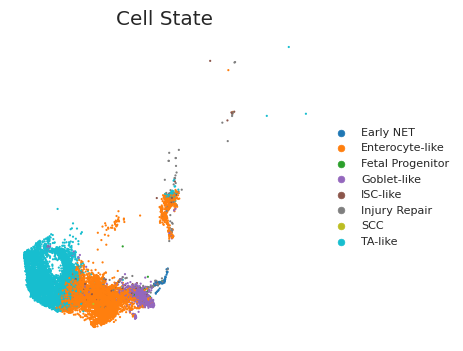

In [176]:
sc.pl.umap(
    adata_org2,
    color= ['Cell State'],
    ncols=1, size=10,
    palette = 'tab10',    
    legend_fontsize=8, vmax=10,
    frameon=False,
)